Load the data and take a first look

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [ ]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print(df.shape)
df.info()


(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [ ]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


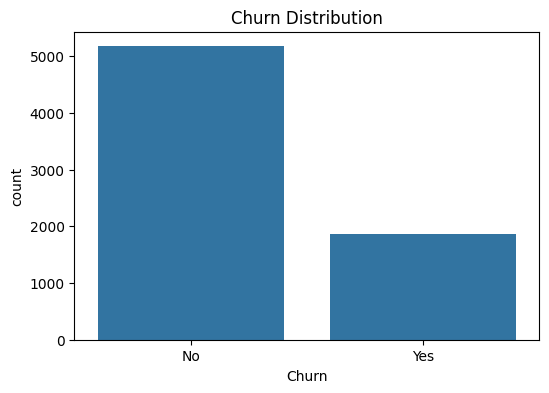

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum())

11


Clean up the data

In [ ]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

Drop customerID, convert Churn to 1/0

In [ ]:
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Split into train/test, and prepare categorical columns

In [ ]:
X = df.drop(columns=['Churn'])
y = df['Churn']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(5634, 19) (1409, 19)


In [ ]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Make sure both sets have exactly the same columns, in the same order
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(X_train.shape, X_test.shape)

(5634, 45) (1409, 45)


Scale the numeric columns

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(X_train_scaled.shape)
print(X_train_scaled[:2])

(5634, 45)
[[-0.44177295  0.10237124 -0.52197565 -0.2622572  -0.99433624  0.99433624
   0.96923413 -0.96923413  0.65155653 -0.65155653  3.01309011 -3.01309011
  -0.95418978  3.01309011 -0.85833837  1.38152871 -0.88769579 -0.52408075
   1.00712513 -0.52408075 -0.63611103  1.14329581 -0.52408075 -0.73554636
  -0.88418532 -0.52408075  1.37557156  1.01646496 -0.52408075 -0.64327425
  -0.80818872 -0.52408075  1.25216312 -0.80549038 -0.52408075  1.24796703
   0.90346421 -0.51278214 -0.56382155  1.20265302 -1.20265302 -0.53232631
  -0.52380561  1.40690298 -0.54384572]
 [-0.44177295 -0.71174346  0.33747781 -0.50363479 -0.99433624  0.99433624
  -1.03174245  1.03174245 -1.53478624  1.53478624 -0.3318852   0.3318852
   1.04800955 -0.3318852  -0.85833837 -0.72383584  1.12651205 -0.52408075
  -0.99292527 -0.52408075  1.57205259  1.14329581 -0.52408075 -0.73554636
   1.13098462 -0.52408075 -0.72697054  1.01646496 -0.52408075 -0.64327425
   1.23733476 -0.52408075 -0.79861799  1.24147976 -0.52408075 -

Train XGBoost with GridSearchCV

In [ ]:
!pip install -q xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV


In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

model = XGBClassifier(random_state=42, eval_metric='logloss')
grid = GridSearchCV(model, param_grid, cv=5, scoring='f1')
grid.fit(X_train_scaled, y_train)

best_xgb = grid.best_estimator_

In [ ]:
print("Best Params:", grid.best_params_)
print("Best CV F1 score:", grid.best_score_)

Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV F1 score: 0.5895404644949563


Evaluate XGBoost on the test set

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_xgb = best_xgb.predict(X_test_scaled)

print("Accuracy: ", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:   ", recall_score(y_test, y_pred_xgb))
print("F1-score: ", f1_score(y_test, y_pred_xgb))

Accuracy:  0.8034066713981547
Precision: 0.6632996632996633
Recall:    0.5267379679144385
F1-score:  0.587183308494784


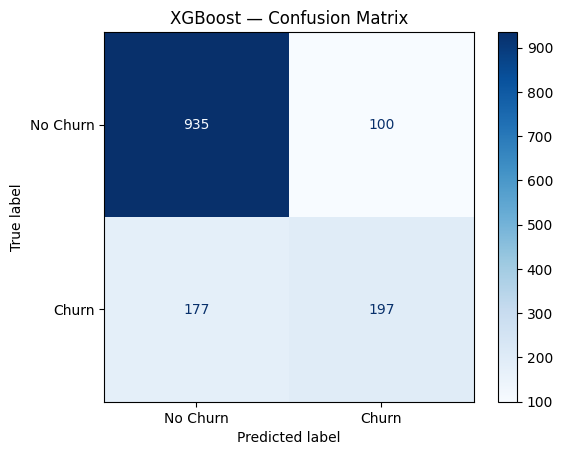

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(cmap='Blues')
plt.title("XGBoost — Confusion Matrix")
plt.show()

Build and tune the MLP with Keras

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [ ]:
def build_mlp(hidden1=64, hidden2=32, learning_rate=0.001):
    model = keras.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(hidden1, activation='relu'),
        layers.Dense(hidden2, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# carve a validation slice out of the training data, just for comparing settings
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)

configs = [
    {'hidden1': 32, 'hidden2': 16, 'learning_rate': 0.001},
    {'hidden1': 64, 'hidden2': 32, 'learning_rate': 0.001},
    {'hidden1': 64, 'hidden2': 32, 'learning_rate': 0.01},
    {'hidden1': 128, 'hidden2': 64, 'learning_rate': 0.001},
]

results = []
for cfg in configs:
    model = build_mlp(**cfg)
    model.fit(X_tr, y_tr, epochs=30, batch_size=32, verbose=0)
    val_pred = (model.predict(X_val, verbose=0) > 0.5).astype(int)
    f1 = f1_score(y_val, val_pred)
    results.append({**cfg, 'val_f1': f1})
    print(cfg, "-> F1:", f1)

{'hidden1': 32, 'hidden2': 16, 'learning_rate': 0.001} -> F1: 0.5855379188712522
{'hidden1': 64, 'hidden2': 32, 'learning_rate': 0.001} -> F1: 0.5798611111111112
{'hidden1': 64, 'hidden2': 32, 'learning_rate': 0.01} -> F1: 0.5447619047619048
{'hidden1': 128, 'hidden2': 64, 'learning_rate': 0.001} -> F1: 0.5669014084507042


Train the winning configuration on the full training set

In [ ]:
best_config = {'hidden1': 32, 'hidden2': 16, 'learning_rate': 0.001}

final_mlp = build_mlp(**best_config)
history = final_mlp.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7480 - loss: 0.4820
Epoch 2/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7957 - loss: 0.4274
Epoch 3/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8009 - loss: 0.4178
Epoch 4/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8044 - loss: 0.4118
Epoch 5/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8083 - loss: 0.4070
Epoch 6/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8083 - loss: 0.4037
Epoch 7/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8133 - loss: 0.4014
Epoch 8/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8106 - loss: 0.4001
Epoch 9/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8135 - loss: 0.3963
Epoch 10/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8166 - loss: 0.3942
Epoch 11/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8170 - loss: 0.3930
Epoch 12/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Predict and score on the test set

In [ ]:
y_prob_mlp = final_mlp.predict(X_test_scaled).ravel()
y_pred_mlp = (y_prob_mlp > 0.5).astype(int)

print("Accuracy: ", accuracy_score(y_test, y_pred_mlp))
print("Precision:", precision_score(y_test, y_pred_mlp))
print("Recall:   ", recall_score(y_test, y_pred_mlp))
print("F1-score: ", f1_score(y_test, y_pred_mlp))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy:  0.7792760823278921
Precision: 0.5940298507462687
Recall:    0.5320855614973262
F1-score:  0.5613540197461213


Confusion matrix

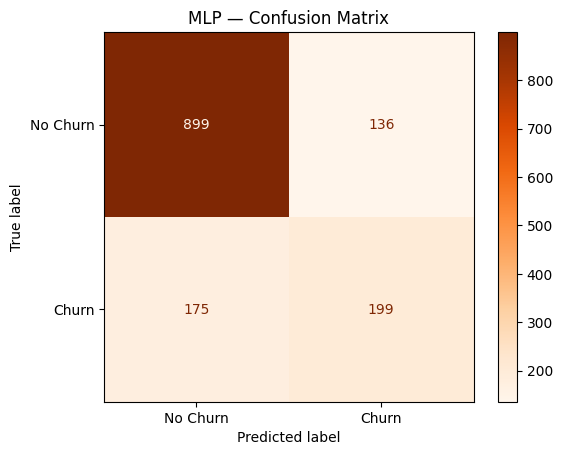

In [ ]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
ConfusionMatrixDisplay(cm_mlp, display_labels=['No Churn', 'Churn']).plot(cmap='Oranges')
plt.title("MLP — Confusion Matrix")
plt.show()

Final comparison table

In [ ]:
comparison_df = pd.DataFrame({
    'XGBoost': {
        'Accuracy': accuracy_score(y_test, y_pred_xgb),
        'Precision': precision_score(y_test, y_pred_xgb),
        'Recall': recall_score(y_test, y_pred_xgb),
        'F1-score': f1_score(y_test, y_pred_xgb),
    },
    'MLP': {
        'Accuracy': accuracy_score(y_test, y_pred_mlp),
        'Precision': precision_score(y_test, y_pred_mlp),
        'Recall': recall_score(y_test, y_pred_mlp),
        'F1-score': f1_score(y_test, y_pred_mlp),
    }
}).round(4)

comparison_df

,XGBoost,MLP
Accuracy,0.8034,0.7793
Precision,0.6633,0.5940
Recall,0.5267,0.5321
F1-score,0.5872,0.5614


A bar chart

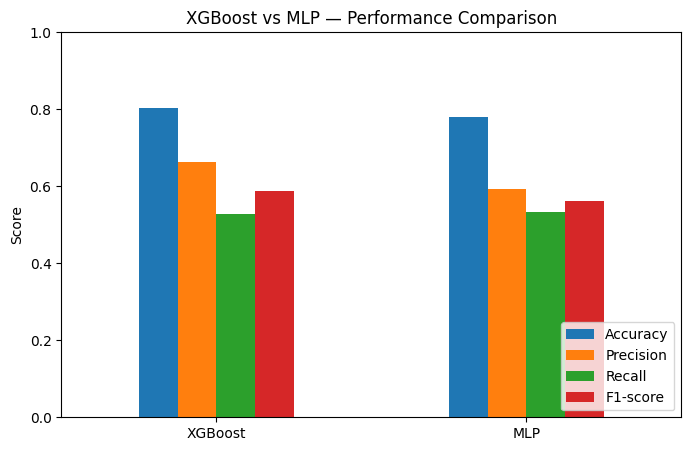

In [ ]:
comparison_df.T.plot(kind='bar', figsize=(8, 5), rot=0)
plt.title("XGBoost vs MLP — Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()

Print the best hyperparameters for both models

In [ ]:
print("Best XGBoost hyperparameters:", grid.best_params_)
print("Best MLP hyperparameters:", best_config)

Best XGBoost hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best MLP hyperparameters: {'hidden1': 32, 'hidden2': 16, 'learning_rate': 0.001}
